In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.DataFrame(
  {
    "Matemáticas": [7.0, 7.5, 7.6, 5.0, 6.0, 7.8, 6.3, 7.9, 6.0, 6.8],
    "Ciencias": [6.5, 9.4, 9.2, 6.5, 6.0, 9.6, 6.4, 9.7, 6.0, 7.2],
    "Español": [9.2, 7.3, 8.0, 6.5, 7.8, 7.7, 8.2, 7.5, 6.5, 8.7],
    "Historia": [8.6, 7.0, 8.0, 7.0, 8.9, 8.0, 9.0, 8.0, 5.5, 9.0],
    "EdFísica": [8.0, 7.0, 7.5, 9.0, 7.3, 6.5, 7.2, 6.0, 8.7, 7.0],
  },
  index=["Lucía", "Pedro", "Inés", "Luis", "Andrés", "Ana", "Carlos", "José", "Sonia", "María"]
)
df

,Matemáticas,Ciencias,Español,Historia,EdFísica
Lucía,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Inés,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andrés,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.5
Carlos,6.3,6.4,8.2,9.0,7.2
José,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7
María,6.8,7.2,8.7,9.0,7.0


In [18]:
X = df - df.mean()

# SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)

# Proyección (coordenadas reducidas)
X_2D = U[:, :2] @ np.diag(S[:2])
X_3D = U[:, :3] @ np.diag(S[:3])

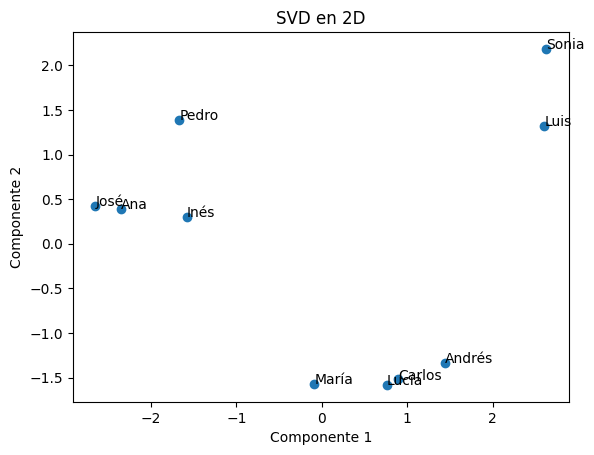

In [19]:
plt.figure()
plt.scatter(X_2D[:,0], X_2D[:,1])

for i, name in enumerate(df.index):
    plt.text(X_2D[i,0], X_2D[i,1], name)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("SVD en 2D")
plt.show()

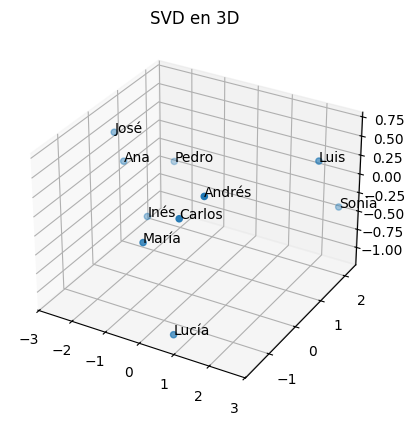

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3D[:,0], X_3D[:,1], X_3D[:,2])

for i, name in enumerate(df.index):
    ax.text(X_3D[i,0], X_3D[i,1], X_3D[i,2], name)

ax.set_title("SVD en 3D")
plt.show()

In [21]:
k = 2

U2 = U[:, :k]
S2 = np.diag(S[:k])
VT2 = VT[:k, :]

X_aprox_2 = U2 @ S2 @ VT2

In [22]:
X_2D = U2 @ S2

In [23]:
k = 3

U3 = U[:, :k]
S3 = np.diag(S[:k])
VT3 = VT[:k, :]

X_aprox_3 = U3 @ S3 @ VT3

In [24]:
X_3D = U3 @ S3

In [25]:
print("U2:\n", U2)
print("S2:\n", S2)
print("VT2:\n", VT2)

U2:
 [[ 0.12929207 -0.37350917]
 [-0.28216001  0.32869126]
 [-0.26683374  0.07072136]
 [ 0.44077212  0.31174587]
 [ 0.24325622 -0.31539761]
 [-0.39696432  0.09164018]
 [ 0.15110369 -0.35866516]
 [-0.44801389  0.10046669]
 [ 0.44458936  0.51557518]
 [-0.01504149 -0.37126859]]
S2:
 [[5.91465079 0.        ]
 [0.         4.2348725 ]]
VT2:
 [[-0.45549913 -0.77308219 -0.11179748 -0.1416005   0.40288347]
 [-0.0301873   0.33663823 -0.53497322 -0.7479026   0.20052126]]


In [28]:
print("\n Caracterìsticas de Grupos")
df_con_grupos = df.copy()
df_con_grupos['Grupo'] = grupos_2d

for grupo in range(3):
    print(f"\nGrupo {grupo}:")
    print(df_con_grupos[df_con_grupos['Grupo'] == grupo].mean())


 Caracterìsticas de Grupos

Grupo 0:
Matemáticas    5.50
Ciencias       6.25
Español        6.50
Historia       6.25
EdFísica       8.85
Grupo          0.00
dtype: float64

Grupo 1:
Matemáticas    6.525
Ciencias       6.525
Español        8.475
Historia       8.875
EdFísica       7.375
Grupo          1.000
dtype: float64

Grupo 2:
Matemáticas    7.700
Ciencias       9.475
Español        7.625
Historia       7.750
EdFísica       6.750
Grupo          2.000
dtype: float64


In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Diferencia máxima:", np.max(np.abs(X_2D - X_pca)))

print("\nVectores principales (SVD):")
print(VT[:2, :])
print("\nComponentes principales (PCA):")
print(pca.components_)
# Los signos pueden estar invertidos, pero la dirección es la misma

Diferencia máxima: 5.299691417283764

Vectores principales (SVD):
[[-0.45549913 -0.77308219 -0.11179748 -0.1416005   0.40288347]
 [-0.0301873   0.33663823 -0.53497322 -0.7479026   0.20052126]]

Componentes principales (PCA):
[[ 0.45549913  0.77308219  0.11179748  0.1416005  -0.40288347]
 [ 0.0301873  -0.33663823  0.53497322  0.7479026  -0.20052126]]
